<a href="https://colab.research.google.com/github/vignesh-potharaj/StudyBot/blob/main/studybot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
#Cell 1 — install
!pip install transformers torch --quiet


In [43]:
# Cell 2 — imports

from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

In [44]:
# Cell 3 — load tokeniser and model
# output_attentions=True tells the model to return attention tensors
# instead of computing them internally and discarding them
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True)
model.eval() # inference mode: no dropout, no gradient tracking
print("Model loaded:", MODEL_NAME)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: distilbert-base-uncased


In [45]:
# Cell 4 — tokenise the study question
# return_tensors="pt" = PyTorch tensors
# add_special_tokens=True adds [CLS] at start, [SEP] at end
question = "Explain Newton's third law of motion."
inputs = tokenizer(question, return_tensors="pt", add_special_tokens=True)
token_ids = inputs["input_ids"][0]
tokens = tokenizer.convert_ids_to_tokens(token_ids)
print("Tokens:", tokens)


Tokens: ['[CLS]', 'explain', 'newton', "'", 's', 'third', 'law', 'of', 'motion', '.', '[SEP]']


In [46]:
# Cell 5 — forward pass
# torch.no_grad() disables gradient computation (saves memory during inference)
# outputs.attentions is a tuple of 6 tensors, one per transformer layer
with torch.no_grad():
 outputs = model(**inputs)
print("Number of attention layers:", len(outputs.attentions)) # 6
print("Layer 0 shape:", outputs.attentions[0].shape)
# torch.Size([1, 12, 11, 11])
# (batch=1, heads=12, from_token=11, to_token=11)


Number of attention layers: 6
Layer 0 shape: torch.Size([1, 12, 11, 11])


In [47]:
def top_attention_pairs(model_outputs, tokens, layer, head, k=5):
    """
    Safely print the top-k attention pairs by explicitly passing dependencies.
    """
    # Ensure attentions exist
    if model_outputs.attentions is None:
        raise ValueError("Model was not loaded with output_attentions=True")

    attn = model_outputs.attentions[layer][0][head].numpy()
    flat = attn.flatten()
    top_idx = flat.argsort()[::-1][:k]

    # Get the matrix dimensions explicitly
    num_rows, num_cols = attn.shape

    print(f"\nLayer {layer}, Head {head}")
    print(f"{'FROM':<14} {'TO':<14} {'WEIGHT':>8}")
    print("-" * 40)
    for idx in top_idx:
        row = idx // num_cols
        col = idx % num_cols
        print(f"{tokens[row]:<14} {tokens[col]:<14} {flat[idx]:.3f}")

# Call it by passing the actual variables:
top_attention_pairs(outputs, tokens, layer=0, head=0, k=5)


Layer 0, Head 0
FROM           TO               WEIGHT
----------------------------------------
newton         motion         0.308
s              [CLS]          0.300
of             [CLS]          0.273
[SEP]          [SEP]          0.266
'              [CLS]          0.265


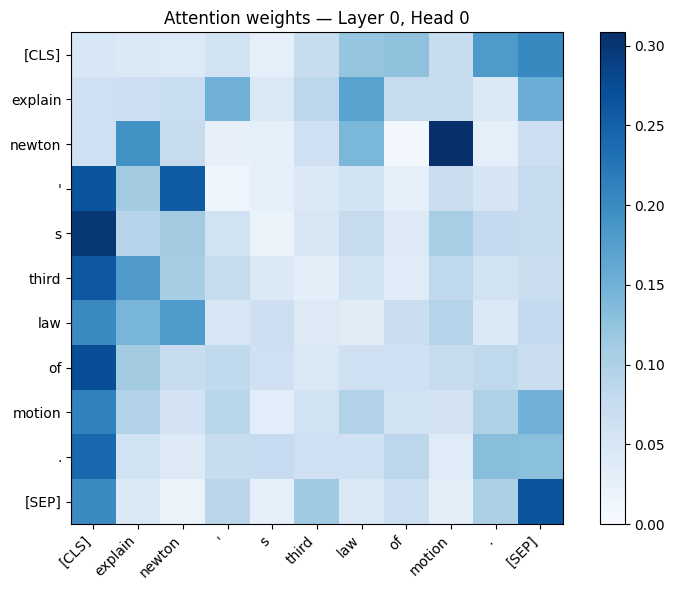

In [48]:
# Cell 7 — visualise attention as a heatmap (bonus)
import matplotlib.pyplot as plt
layer, head = 0, 0
attn = outputs.attentions[layer][0][head].numpy()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(attn, cmap="Blues", vmin=0, vmax=attn.max())
ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=45,
ha="right")
ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens)
ax.set_title(f"Attention weights — Layer {layer}, Head {head}")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [49]:
# Install the modern official Google GenAI package
!pip install google-genai --quiet

import os
from google import genai
from google.genai import types

In [50]:
SYSTEM_PROMPTS = {

    "beginner": """You are StudyBot, a friendly tutor for first-year students.
Rules:
- Use only everyday words. Avoid jargon. If you must use a technical term, define it immediately.
- Use a simple real-world analogy first, then explain the concept.
- Keep your answer to 3–4 sentences maximum.
- End with one encouraging sentence.
Example of your tone: 'Great question! Think of it like...'
""",

    "intermediate": """You are StudyBot, a concise engineering tutor for second or third-year students.
Rules:
- Assume the student knows basic calculus and Python.
- Explain the concept, then show the key formula, then a one-paragraph worked example.
- Use bullet points for the algorithm steps.
- Keep the total response under 200 words.
""",

    "expert": """You are StudyBot, a graduate-level AI research assistant.
Rules:
- The student is a final-year or postgraduate student. Skip basic definitions.
- Discuss convergence properties, common failure modes, and practical trade-offs.
- Compare at least two variants (e.g. SGD vs Adam) with their mathematical motivation.
- Include pseudocode if relevant.
- Use precise mathematical notation.
"""
}

In [51]:
# Initialize the Gemini client
# Note: Ensure you have your key stored in your environment or Colab secrets as 'GEMINI_API_KEY'
client = genai.Client()

def ask_studybot(question: str, level: str) -> str:
    """Send the question with the appropriate Gemini system instruction configuration."""

    # Configure parameters, passing the prompt system rules into system_instruction
    config = types.GenerateContentConfig(
        system_instruction=SYSTEM_PROMPTS[level],
        max_output_tokens=512
    )

    # We use gemini-2.5-flash as the standard efficient frontier model
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=question,
        config=config
    )

    return response.text

ValueError: No API key was provided. Please pass a valid API key. Learn how to create an API key at https://ai.google.dev/gemini-api/docs/api-key.

In [ ]:
question = "What is gradient descent?"

responses = {}
for level in ["beginner", "intermediate", "expert"]:
    print(f"\n{'='*60}")
    print(f"LEVEL: {level.upper()}")
    print('='*60)
    responses[level] = ask_studybot(question, level)
    print(responses[level])

In [ ]:
import re

def word_count(text):
    return len(text.split())

def avg_word_len(text):
    words = re.findall(r'\b\w+\b', text)
    return round(sum(len(w) for w in words)/len(words), 1) if words else 0

print(f"\n{'Metric':<25} {'Beginner':>12} {'Intermediate':>14} {'Expert':>10}")
print("-" * 65)
for key, label, fn in [
    ("word_count",    "Word count",        word_count),
    ("avg_word_len",  "Avg word length",   avg_word_len),
]:
    row = {lvl: fn(responses[lvl]) for lvl in ["beginner","intermediate","expert"]}
    print(f"{label:<25} {row['beginner']:>12} {row['intermediate']:>14} {row['expert']:>10}")